


## Import and post-process e-ph coupling calculation
Convert e-ph couplings to MO subspace, and then convert that to multiconfigurational singlet subspace spanned by symmetric/antisymmetric singlet exciton ($\mathrm{SE}_\pm$), charge transfer ($\mathrm{CT}_\pm$) and correlated triplet ($\mathrm{TT}$) states.

In [1]:
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
from dftutils import mf_from_chk
from ephutils import multiconfig_vibronic_coupling, effective_spectral_density, \
                     vectorize_ephmat, cluster_ephmat, cluster_indices, \
                     eigh_block, nn_block_mapping                     
from visutils import view_vibration_distorted, view_vibration_animation, view_vibration_arrows, \
                     view_multiconfig_vibronic_coupling, show_matrix

HARTREE2EV = 27.2114079527
HARTREE2ICM = 219474.63

# Directories for source data and results
DATADIR = os.path.realpath("../runs/10264877/")
SAVEDIR = os.path.realpath("../results/")
PLOTDIR = os.path.realpath("../plots/")

plt.rcParams.update({
    "font.size": 16,        # base font size
    "axes.labelsize": 18,   # x/y labels
    "axes.titlesize": 20,   # title
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

In [ ]:
import py3Dmol
from ephutils import cartesian_modevec
from dftutils import xyz_string

def view_vibration_animation_gif(mol_obj, modevec, amplitude=0.5, period=1000, fps=60, gif=None):
    """
    Visualize vibrational animation along a vibrational mode.
    Generate view with py3Dmol which can be displayed as view.show().
    """
    view = py3Dmol.view(width=600, height=300)
    symbols = mol_obj.elements
    coords = mol_obj.atom_coords(unit="Angstrom")
    mass = mol_obj.atom_mass_list()
    displacement = amplitude * cartesian_modevec(modevec, mass)
    xyz_frames = ""
    # calculate number of frames from period (ms) and fps
    nframes = round(period / 1000 * fps)
    times = np.linspace(0, 2*np.pi, nframes+1)[:-1]
    for t in times:
        coords_distorted = coords + np.sin(t) * displacement
        xyz_frames += xyz_string(symbols, coords_distorted, filename=False)
    view.addModelsAsFrames(xyz_frames, "xyz")
    view.animate({"loop" : "forward", 
                  "reps" : 0,
                  "interval" : period / nframes})
    view.setStyle({"stick":{"colorscheme":"grayCarbon"}})
    view.setViewStyle({"style": "outline"})
    view.setBackgroundColor("white")
    view.zoomTo()
    view.rotate(-45, "x")
    view.zoom(1.5)
    if gif is not None:
        import tempfile,time
        import imageio.v2 as imageio
        from pathlib import Path
        from selenium import webdriver
        from selenium.webdriver.chrome.options import Options
        html_template="""<html><head><script src="https://3Dmol.org/build/3Dmol-min.js"></script></head><body><div id="viewer" style="width:600px;height:300px;"></div><script>let config={xyz_data};let viewer=$3Dmol.createViewer("viewer",{backgroundColor:"white"});viewer.addModelsAsFrames(config,"xyz");viewer.setStyle({stick:{colorscheme:"grayCarbon"}});viewer.setViewStyle({style:"outline"});viewer.zoomTo();viewer.rotate(-45,"x");viewer.zoom(1.5);viewer.render();window.viewer=viewer;</script></body></html>"""
        nframes=round(period/1000*fps)
        times=np.linspace(0,2*np.pi,nframes+1)[:-1]
        xyz_frames=""
        for t in times:
            coords_distorted=coords+np.sin(t)*displacement
            xyz_frames+=xyz_string(symbols,coords_distorted,filename=False)
        tmpdir=Path(tempfile.mkdtemp())
        html_file=tmpdir/"viewer.html"
        html_file.write_text(html_template.format(xyz_data=repr(xyz_frames)))
        chrome_options=Options()
        chrome_options.add_argument("--headless=new")
        chrome_options.add_argument("--window-size=600,300")
        driver=webdriver.Chrome(options=chrome_options)
        driver.get(f"file://{html_file}")
        time.sleep(2)
        images=[]
        for i in range(nframes):
            driver.execute_script(f"window.viewer.setFrame({i});window.viewer.render();")
            time.sleep(0.05)
            images.append(imageio.imread(driver.get_screenshot_as_png()))
        driver.quit()
        imageio.mimsave(gif,images,duration=period/1000/nframes,loop=0)    
    return view


In [2]:
# Import DFT data
mf = mf_from_chk(DATADIR + "/" + "calc.chk")
mol = mf.mol
h5file = DATADIR + "/" + "loc.h5"
with h5py.File(h5file, "r") as f:
    fock_ao = np.array(list(f["fock_ao"])) # hartree
    mo_coeff_block = np.array(list(f["mo_coeff_block"]))
    integral2e = np.array(list(f["integral2e"]))

In [4]:
# Visualize orbitals
from visutils import view_orbital
for i, mo in enumerate(mo_coeff_block.T):
    orbname = SAVEDIR + "/" + "orbBlock" + str(i+1) + ".cube"
    v = view_orbital(mol, orbname, iso=0.02, alpha=0.9, html=True)

In [3]:
# Import EPH data
h5file = DATADIR + "/" + "out.h5"
with h5py.File(h5file, "r") as f:
    ephmat  = np.array(list(f["ephmat"])) * HARTREE2ICM
    omega   = np.array(list(f["omega"])) * HARTREE2ICM
    modevec = np.array(list(f["modevec"])) # mass-weighted

# Convert ephmat from AO to MO subspace (units cm^-1)
g = np.einsum('kij, ip, jq -> kpq', ephmat,
                                    mo_coeff_block, 
                                    mo_coeff_block, 
                                    optimize=True)

# Convert from MO subspace to multiconfigurational singlet subspace
lvc = multiconfig_vibronic_coupling(g, which="Smith")

### SVD

Identify strongly coupled modes using SVD on the e-ph coupling matrix,
$$
g_{\alpha,ij} = \sum_k U_{\alpha k} s_k V^{\dagger}_{k,ij},
$$
where $\alpha$ labels normal modes, $i,j$ label electronic states, and $k$ labels the effective modes extracted via SVD.

[Younas et al. (2024) https://doi.org/10.48550/arXiv.2407.08043].

/var/folders/w5/_wg8zp6151qgmdqjbkqpfz3c0000gn/T/ipykernel_57086/543288463.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Iterative SVD and block diagonalization:
Block nr. 	 Frequencies (cm^-1) 	 Coupling to previous block (cm^-1)
0 		 553.9290739337116 	 88.03963066343866
  		 642.5845574743157 	 53.42811181210262
  		 693.8651512815396 	 84.06674905967391
  		 758.6599857425529 	 62.90906267854735
------------------------------------------------------------
1 		 2223.967229993292 	 1246.1238526506233
  		 2464.97235711019 		
  		 2540.6537245767613 		
  		 2577.1395401105765 		
------------------------------------------------------------
2 		 673.76827490616 	 1670.2933469530267
  		 779.9007315382242 		
  		 943.8256900623211 		
  		 1391.3032335459573 		
------------------------------------------------------------
3 		 558.4818028475838 	 444.6670768302773
  		 696.4105817619206 		
  		 803.6776350354605 		
  		 1820.7961218975204 		
------------------------------------------------------------
4 		 1577.5977333538287 	 1739.6235373193656
  		 2551.054772731352 		
  		 2627.1665431733354 		
  		 2776.

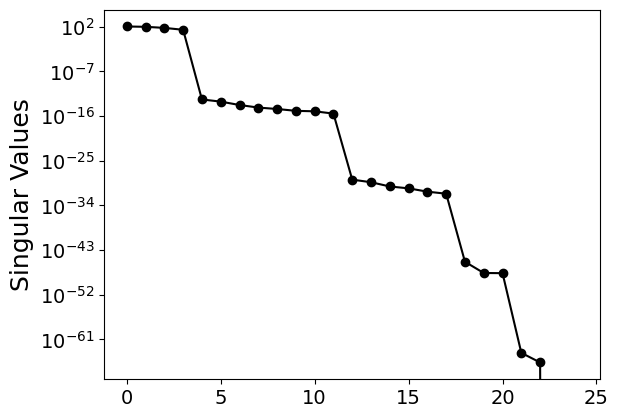

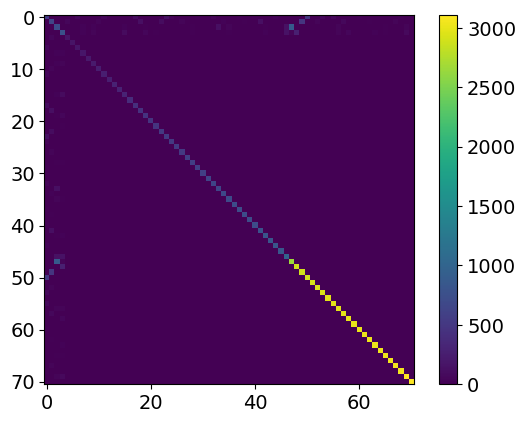

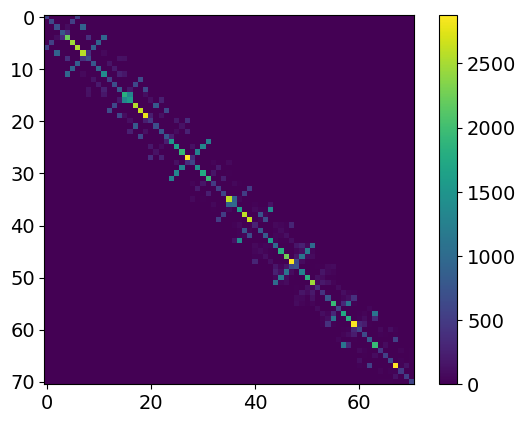

In [4]:
data = vectorize_ephmat(lvc, normalize=False)

#kboltzmann = 0.6950348004861274 # cm^-1 / K
#temperature = 300
#nocc = 1 / (np.exp(omega/kboltzmann/temperature) - 1)
#data = np.einsum("k, ki -> ki", np.sqrt(nocc), data)
#data = np.einsum("k, ki -> ki", np.sqrt(nocc+1), data)

u, s, vh = np.linalg.svd(data)

fig, ax = plt.subplots()
ax.semilogy(s, 'ko-')
ax.set_ylabel("Singular Values")
fig.show()
fig.savefig(PLOTDIR + "/" + "singular_values.pdf", bbox_inches="tight")

ns = np.count_nonzero(s > s[0] * 1e-8)
s = s[:ns]
vh = vh[:ns]
# transformed system operators (nsvd, nel, nel)
lvc_svd = vh.reshape(ns, lvc.shape[1], lvc.shape[2])
# transformed mode displacements (3*nat, nvib)
modevec_svd = modevec @ u
# transformed vibrational Hamiltonian
hvib = u.T @ np.diag(omega) @ u
# diagonalize vib Hamiltonian in the SVD subspace
hvib, ublock = eigh_block(hvib, ns)
# transformed frequencies
omega_svd = np.diag(hvib)
# transformed mode vectors
modevec_svd = modevec_svd @ ublock
# transformed system-bath couplings
lvc_svd = np.einsum('kij,k,kl -> lij', lvc_svd, s, ublock[:ns,:ns], optimize=True)
# coupling strengths
s = [np.linalg.norm(l) for l in lvc_svd]


logscale = False
f = show_matrix(hvib, logscale=logscale)
f.savefig(PLOTDIR + "/" + "rc_mapping.pdf", bbox_inches="tight")
hvib_block, _, blocks = nn_block_mapping(hvib, ns)
omega_block = np.diag(hvib_block).real
f = show_matrix(hvib_block, logscale=logscale)
f.savefig(PLOTDIR + "/" + "rc_mapping_iter.pdf", bbox_inches="tight")

print("Iterative SVD and block diagonalization:")
print("Block nr. \t Frequencies (cm^-1) \t Coupling to previous block (cm^-1)")
for i in range(ns):
    if i==0: print("0", "\t\t", omega_svd[i], "\t", s[i])
    else:    print(" ", "\t\t", omega_svd[i], "\t", s[i])
for k in range(1,len(blocks)):
    print("-"*60)
    b = blocks[k]
    start = sum(blocks[:k])
    stop = start + b
    vblock = hvib_block[start:stop].T[(start-blocks[k-1]):start]
    for i in range(start,stop):
        if i==start: print(k,   "\t\t", omega_block[i], "\t", np.linalg.norm(vblock))
        else:        print(" ", "\t\t", omega_block[i], "\t\t")



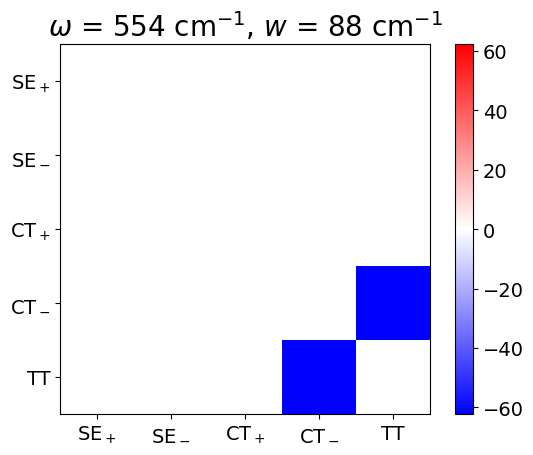

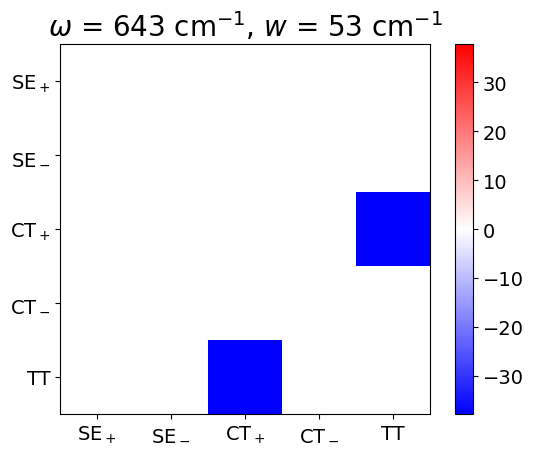

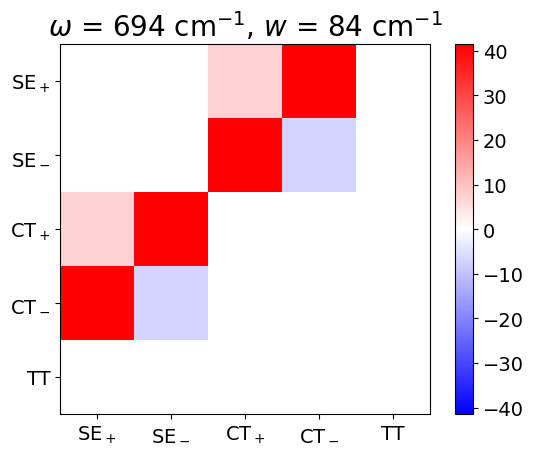

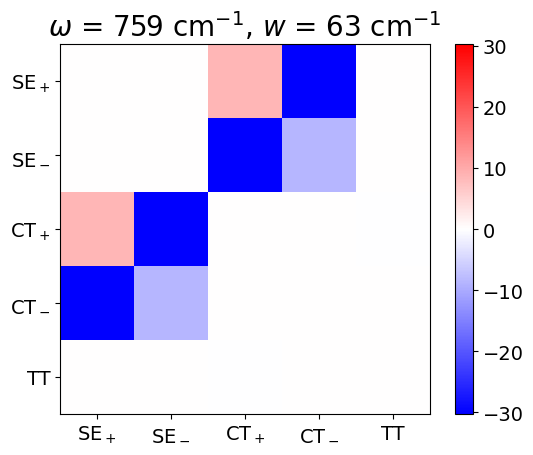

In [5]:
for i in range(ns):
    matr = lvc_svd[i]
    freq, coup = omega_svd[i], s[i]
    vec = modevec_svd[:,i]
    f = view_multiconfig_vibronic_coupling(matr, frequency=freq, coupling=coup)
    f.savefig(PLOTDIR + "/" + "vibronic_operator_" + str(i) + ".pdf", bbox_inches="tight")
    gifname = PLOTDIR + "/" + "vibration_" + str(i) + ".gif"
    v = view_vibration_animation(mol, vec, amplitude=.8, period=1000, fps=60, gif=gifname)


### IDEA:
Linear vibronic coupling in a system of size $N$ coupled to $M$ normal modes is represented by a $M \times N^2$ dimensional tensor $g_{\alpha, ij}$.
1. SVD on $g_{\alpha, ij}$ gives $K_1 \leq N^2$ relevant modes coupled to the system
2. block-diagonalize $H_\mathrm{vib}$ in $K_1$-dim relevant and $(M-K_1)$-dim irrelevant blocks
3. (transform the e-ph coupling accordingly)
4. SVD on coupling between relevant and irrelevant blocks, gives at most $K_2 \leq K_1$ relevant modes for the second layer
5. block-diagonalize $H_\mathrm{vib}$ in $K_2$-dim relevant and $(M-K_1-K_2)$-dim irrelevant blocks
6. repeat steps 4-5 until no modes are left


## Exchange coupling spectral density
Triplet-triplet exchange coupling is proportional to $\sqrt{3} t^2_{h_\mathrm{A}l_\mathrm{B}}$.
Since $t^2_{h_\mathrm{A}l_\mathrm{B}} \approx 0$ at the equilibrium geometry due to symmetry, the vibronic coupling is just proportional to the gradient $2\sqrt{3}\partial_k t_{h_\mathrm{A}l_\mathrm{B}}$.
The resulting spectral density can be calculated as follows:

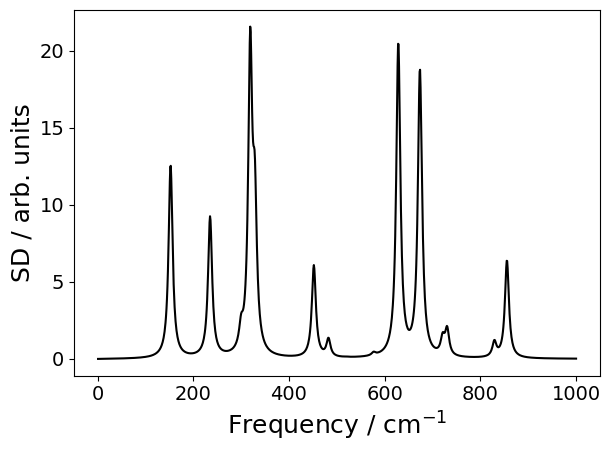

<Figure size 640x480 with 0 Axes>

In [37]:
hwhm, wmax = 5, 1000
fgrid = np.linspace(1,wmax,int(wmax))
jgrid = effective_spectral_density(fgrid, omega, g[:,1,2], hwhm=5, plot=False)
plt.figure()
plt.plot(fgrid, jgrid, "k-")
plt.xlabel(r"Frequency / cm$^{-1}$")
plt.ylabel(r"SD / arb. units")
plt.tight_layout()
plt.show()
plt.savefig(PLOTDIR + "/" + "tt_spectral_density.pdf", bbox_inches="tight")


Iterative SVD and block diagonalization:
Block nr. 	 Frequencies (cm^-1) 	 Coupling to previous block (cm^-1)
0 		 577.8833793686027 	 1.0
------------------------------------------------------------
1 		 2509.925083596387 	 550.7940016071049
------------------------------------------------------------
2 		 840.3801591499762 	 880.9438812426304
------------------------------------------------------------
3 		 644.920688446468 	 191.0366129523789
------------------------------------------------------------
4 		 2448.385874441796 	 607.0206218272807
------------------------------------------------------------
5 		 939.8020256232167 	 897.6494055818333
------------------------------------------------------------
6 		 1393.5827313152527 	 167.16938511418954
------------------------------------------------------------
7 		 2030.9595448873772 	 1237.6415929272614
------------------------------------------------------------
8 		 570.3797205175996 	 250.4585025664968
--------------------------

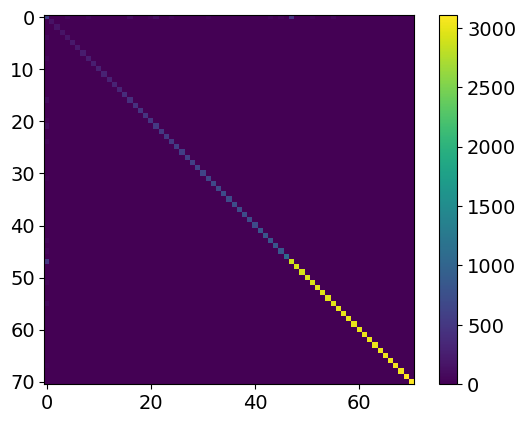

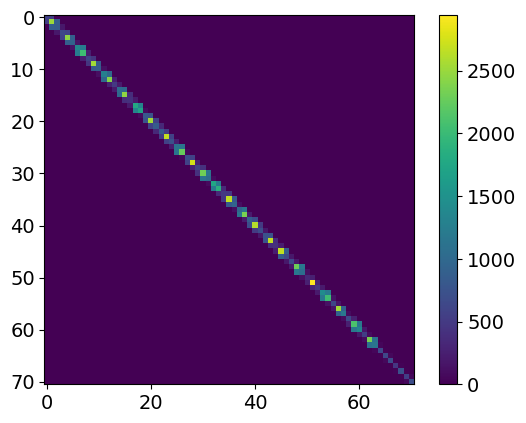

In [39]:
data = g[:,1,2].reshape(len(g),1)
ns=1

#kboltzmann = 0.6950348004861274 # cm^-1 / K
#temperature = 77
#nocc = 1 / (np.exp(omega/kboltzmann/temperature) - 1)
#data = np.einsum("k, ki -> ki", np.sqrt(nocc), data)
#data = np.einsum("k, ki -> ki", np.sqrt(nocc+1), data)

u, s, vh = np.linalg.svd(data)
ns = np.count_nonzero(s > s[0] * 1e-8)
s = s[:ns]
vh = vh[:ns]
# transformed system operators (nsvd, nel, nel)
lvc_svd = vh.reshape(ns, 1)
# transformed mode displacements (3*nat, nvib)
modevec_svd = modevec @ u
# transformed vibrational Hamiltonian
hvib = u.T @ np.diag(omega) @ u
# diagonalize vib Hamiltonian in the SVD subspace
hvib, ublock = eigh_block(hvib, ns)
# transformed frequencies
omega_svd = np.diag(hvib)
# transformed mode vectors
modevec_svd = modevec_svd @ ublock
## transformed system-bath couplings
##lvc_svd = np.einsum('kij,k,kl -> lij', lvc_svd, s, ublock[:ns,:ns], optimize=True)
# coupling strengths
s = [np.linalg.norm(l) for l in lvc_svd]


logscale = False
f = show_matrix(hvib, logscale=logscale)
f.savefig(PLOTDIR + "/" + "tt_rc_mapping.pdf", bbox_inches="tight")
hvib_block, _, blocks = nn_block_mapping(hvib, ns)
omega_block = np.diag(hvib_block).real
f = show_matrix(hvib_block, logscale=logscale)
f.savefig(PLOTDIR + "/" + "tt_rc_mapping_iter.pdf", bbox_inches="tight")

print("Iterative SVD and block diagonalization:")
print("Block nr. \t Frequencies (cm^-1) \t Coupling to previous block (cm^-1)")
for i in range(ns):
    if i==0: print("0", "\t\t", omega_svd[i], "\t", s[i])
    else:    print(" ", "\t\t", omega_svd[i], "\t", s[i])
for k in range(1,len(blocks)):
    print("-"*60)
    b = blocks[k]
    start = sum(blocks[:k])
    stop = start + b
    vblock = hvib_block[start:stop].T[(start-blocks[k-1]):start]
    for i in range(start,stop):
        if i==start: print(k,   "\t\t", omega_block[i], "\t", np.linalg.norm(vblock))
        else:        print(" ", "\t\t", omega_block[i], "\t\t")


## Idea:
### We already have the vibronic coupling in the full MO basis - let's use it

Instead of doing SVD to identify the vibronic coupling patterns in a small pre-selected electroinc state manifold, we could use the information from more than those four frontier molecular orbitals?

This is the same as identifying a preferred vibronic basis?
Identify hieararchies with SVD.

### Clustering

Identify significant mode coupling patterns doing K-means clustering on the e-ph coupling matrix.

[Schroder et al. (2019) https://doi.org/10.1038/s41467-019-09039-7]

In [ ]:
data = vectorize_ephmat(lvc, normalize=True)
kmeans = cluster_ephmat(data, n_clusters=10, plot=True)

The cells below contain a lot of code that could just be transferred to the utility modules ```visutils``` and ```ephutils```.

In [ ]:
# Run clustering for different number of clusters and plot inertia
ks = list(range(2,19))
inertia = []
for k in ks:
    kmeans = cluster_ephmat(data, n_clusters=k, plot=False)
    inertia += [kmeans.inertia_]
plt.figure()
plt.semilogy(ks, inertia, "ko-")
plt.xticks(ks)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia (arb. units)")
plt.tight_layout()
plt.show()


In [ ]:
# Find mode clusters
nc = 10
data = vectorize_ephmat(lvc, normalize=True)
kmeans = cluster_ephmat(data, n_clusters=nc, plot=False)
indices = cluster_indices(kmeans.labels_)
# Plot spectral density
hwhm, wmax = 5, 1000
fgrid = np.linspace(1,wmax,int(wmax))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, nc))
yshift = 2000
plt.figure()
for n in range(nc):
    # find indices of modes belonging to current cluster
    idx = indices[n]
    x, y, z = omega[idx], lvc[idx], hwhm
    jgrid = effective_spectral_density(fgrid, x, y, z, plot=False) + yshift * n
    plt.plot(fgrid, jgrid, '-', color=colors[n])
# total effective spectral density
jtot = effective_spectral_density(fgrid, omega, lvc, plot=False)
jtot = jtot + yshift * nc
plt.plot(fgrid, jtot, "k-", linewidth=2)
plt.xlabel(r"Frequency / cm$^{-1}$")
plt.ylabel(r"Spectral Density / cm$^{-1}$")
plt.tight_layout()
plt.show()


In [ ]:
# --- reaction coordinate of each cluster (frequency, coupling) ---
nc = 10
data = vectorize_ephmat(lvc, normalize=True)
kmeans = cluster_ephmat(data, n_clusters=nc, plot=False)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
nc = centroids.shape[0]
centroids = centroids.reshape(nc, 5, 5)

cluster_freq, cluster_coup = [], []
centroid_freq, centroid_coup = [], []
centroid_sd = []

for cluster_label in range(nc):

    # normalise cluster centroid
    wc = centroids[cluster_label]
    wc_norm = np.linalg.norm(wc)
    wc = wc / wc_norm

    # rescale cluster elements
    w_cluster = lvc[labels==cluster_label] * wc_norm

    # cluster couplings and frequencies
    w_coup = np.linalg.norm(w_cluster, axis=(1,2))
    w_freq = omega[labels==cluster_label]
    
    # reaction coordinate coupling and frequency
    rc_coup = np.sqrt(np.sum(w_coup**2))
    rc_freq = np.sum(w_freq * w_coup**2) / rc_coup**2

    # store results
    cluster_coup += [w_coup]
    cluster_freq += [w_freq]
    centroid_coup += [rc_coup]
    centroid_freq += [rc_freq]
    #centroid_sd += [rc_sd]

print("Cluster RC frequency, coupling (cm^-1) ")
print(np.array([centroid_freq, centroid_coup]).T)
